# Task (c) — Distributions of hits and tracks in $x$, $y$ and $\varphi$

Task (b) produced the dataset `data/events_2d_10k.csv`: **10,000 events, 10 tracks
each**, with 95% hit efficiency and Gaussian position smearing $\sigma = 0.001\,R$.
Task (c) asks for histograms of the **hits** and the **tracks** in $x$, $y$ and
$\varphi$ (the angle relative to the $x$-axis).

What exactly we histogram:

| Quantity | Hits | Tracks |
|---|---|---|
| $x,\ y$ | recorded (smeared) hit positions | components of the unit **direction vector** $(\cos\varphi, \sin\varphi)$ |
| $\varphi$ | $\varphi_\mathrm{hit} = \operatorname{atan2}(y, x)$ | the true track parameter $\varphi$ (one entry per track) |

A straight track from the origin is fully described by its *single* parameter
$\varphi$ — a ray has no unique $(x, y)$ point. The natural "$x$ and $y$ of a
track" are therefore the components of its unit direction vector, and we say so
explicitly rather than silently histogramming something else.

Because the simulation is a known Monte Carlo, every histogram has an **analytic
expectation** we can overlay — this doubles as a validation of tasks (a)/(b).

### Setup

In [1]:
import sys, os

def add_project_root_to_path():
    here = os.path.abspath(os.getcwd())
    while here != os.path.dirname(here):
        if os.path.isdir(os.path.join(here, "src")):
            if here not in sys.path: sys.path.insert(0, here)
            return here
        here = os.path.dirname(here)
    raise RuntimeError("Project root containing 'src/' not found.")
ROOT = add_project_root_to_path()

import numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy.stats import chisquare, chi2 as scipy_chi2
from src.simulator import detector_radii, simulate_events

RADII = detector_radii(5, 2.0); SMEAR = 0.001; EFF = 0.95
FIGDIR = os.path.join(ROOT, "figures")
DATA = os.path.join(ROOT, "data", "events_2d_10k.csv")

# Load the task-b dataset; regenerate deterministically (same seed) if missing.
if not os.path.exists(DATA):
    simulate_events(10000, seed=2026, n_tracks=10,
                    efficiency=EFF, smear=SMEAR).to_csv(DATA, index=False)
df = pd.read_csv(DATA)

# Hit angle relative to the x-axis, wrapped to [0, 2*pi) like the track phi.
df["phi_hit"] = np.mod(np.arctan2(df["y"], df["x"]), 2.0 * np.pi)

# One row per (event, track): the true track parameters.
tracks = df.drop_duplicates(["event_id", "track_id"])[["event_id", "track_id", "phi"]]
print(f"{len(df):,} hits and {len(tracks):,} tracks "
      f"(10,000 x 10 = 100,000 generated; a track only disappears if all 5 of "
      f"its hits are lost, P = 0.05^5 ~ 3e-7, so we expect ~0 missing)")

475,028 hits and 100,000 tracks (10,000 x 10 = 100,000 generated; a track only disappears if all 5 of its hits are lost, P = 0.05^5 ~ 3e-7, so we expect ~0 missing)


## 1. Hits in $x$ and $y$ — the arcsine law

For one circle of radius $R$ and an isotropic track angle
$\varphi \sim U[0, 2\pi)$, the hit abscissa $x = R\cos\varphi$ has CDF

$$F_R(x) = \tfrac{1}{2} + \tfrac{1}{\pi}\arcsin(x/R), \qquad
f_R(x) = \frac{1}{\pi\sqrt{R^2 - x^2}}, \quad |x| < R ,$$

the **arcsine law**: U-shaped, with integrable singularities at $\pm R$
(the circle is "flat" against a vertical line there, so hits pile up).
The recorded hits are an **equal-weight mixture over the five layers** — the 95%
efficiency removes hits independently of $\varphi$ and layer, so it cancels in
the normalisation — hence we expect peaks at $\pm 2, \pm 4, \pm 6, \pm 8, \pm 10$.
By symmetry $y = R\sin\varphi$ has the same distribution.

Instead of evaluating the (divergent) density at bin centres we overlay the
**bin-integrated** expectation $\big(F_R(x_{i+1}) - F_R(x_i)\big)/\Delta x$,
which is exact and finite in every bin. The $\sigma = 0.001R \le 0.01$ smearing
is far below the 0.1 bin width, so it is invisible here.

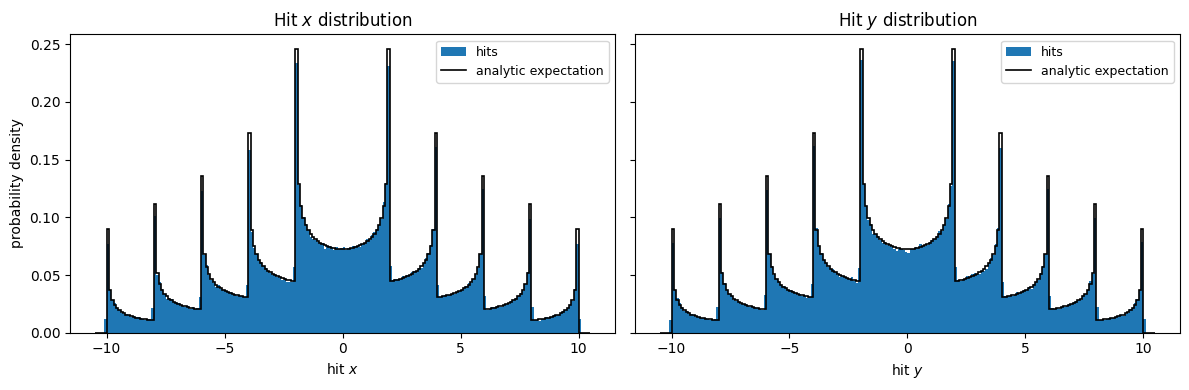

In [2]:
def arcsine_cdf(x, R):
    """CDF of x = R*cos(phi) for uniform phi: F(x) = 1/2 + arcsin(x/R)/pi."""
    return 0.5 + np.arcsin(np.clip(x / R, -1.0, 1.0)) / np.pi

def mixture_bin_density(edges, radii):
    """Expected histogram density in each bin for the equal-weight layer mixture."""
    p = np.zeros(len(edges) - 1)
    for R in radii:
        p += (arcsine_cdf(edges[1:], R) - arcsine_cdf(edges[:-1], R)) / len(radii)
    return p / np.diff(edges)

edges = np.linspace(-10.5, 10.5, 211)          # 0.1-wide bins
expected = mixture_bin_density(edges, RADII)

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for ax, coord in zip(axes, ["x", "y"]):
    ax.hist(df[coord], bins=edges, density=True, color="tab:blue", label="hits")
    ax.stairs(expected, edges, color="k", lw=1.2, label="analytic expectation")
    ax.set_xlabel(f"hit ${coord}$"); ax.set_title(f"Hit ${coord}$ distribution")
    ax.legend(fontsize=9)
axes[0].set_ylabel("probability density")
fig.tight_layout(); fig.savefig(os.path.join(FIGDIR, "c1_hit_x_y.png"), dpi=150)
plt.show()

## 2. Hits in $\varphi$ — isotropy

The hit angle should be **uniform on $[0, 2\pi)$**: tracks are emitted
isotropically, the efficiency is angle-independent, and the smearing is
rotationally symmetric.

**A statistical subtlety.** The hits are *not* independent draws from the
uniform distribution: the $m \sim \mathrm{Binomial}(5,\,0.95)$ hits of one track
share the same $\varphi$ to within ~1 mrad (section 4), i.e. they land in the
*same* 5° bin as a cluster. Clustered counts are overdispersed relative to
Poisson by the mean cluster size weighted by cluster size,

$$c = \mathbb{E}[m^2]\,/\,\mathbb{E}[m] \approx 4.8,$$

so the naive $\chi^2$ comes out ~4.8 times too large and would wrongly reject
uniformity. The corrected statistic is $\chi^2 / c$ (equivalently: the
effective number of independent entries per bin is the number of *tracks*, not
hits). We report both.

hits in phi:  naive chi2/ndf = 311.4/71  (inflated: correlated hits)
cluster factor c = E[m^2]/E[m] = 4.80
corrected chi2/ndf = 64.9/71,  p = 0.682


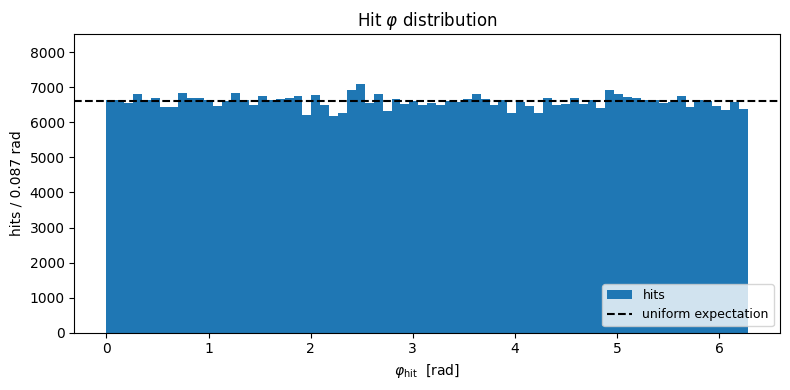

In [3]:
NB_PHI = 72                                     # 5-degree bins
counts, edges_phi = np.histogram(df["phi_hit"], bins=NB_PHI, range=(0.0, 2.0 * np.pi))
stat, _ = chisquare(counts)                     # naive: assumes independent hits

# Overdispersion factor from the empirical cluster (hits-per-track) sizes.
per_track = df.groupby(["event_id", "track_id"]).size()
c = (per_track**2).mean() / per_track.mean()
pval = scipy_chi2.sf(stat / c, NB_PHI - 1)
print(f"hits in phi:  naive chi2/ndf = {stat:.1f}/{NB_PHI - 1}  (inflated: correlated hits)")
print(f"cluster factor c = E[m^2]/E[m] = {c:.2f}")
print(f"corrected chi2/ndf = {stat / c:.1f}/{NB_PHI - 1},  p = {pval:.3f}")

fig, ax = plt.subplots(figsize=(8, 4))
ax.stairs(counts, edges_phi, fill=True, color="tab:blue", label="hits")
ax.axhline(len(df) / NB_PHI, color="k", ls="--", label="uniform expectation")
ax.set_xlabel(r"$\varphi_\mathrm{hit}$  [rad]")
ax.set_ylabel(f"hits / {2 * np.pi / NB_PHI:.3f} rad")
ax.set_ylim(0, counts.max() * 1.2)              # full scale: fluctuations are small
ax.set_title(r"Hit $\varphi$ distribution"); ax.legend(fontsize=9, loc="lower right")
fig.tight_layout(); fig.savefig(os.path.join(FIGDIR, "c2_hit_phi.png"), dpi=150)
plt.show()

## 3. Tracks in $\varphi$, $x$ and $y$

One entry **per track** (not per hit). The track parameter $\varphi$ is sampled
uniformly, so its histogram should be flat ($\chi^2$ test again). The direction
components $u_x = \cos\varphi$ and $u_y = \sin\varphi$ follow the arcsine law
with $R = 1$ — the same overlay machinery as section 1 with a single "layer".

tracks in phi: chi2/ndf = 65.4/71,  p = 0.666


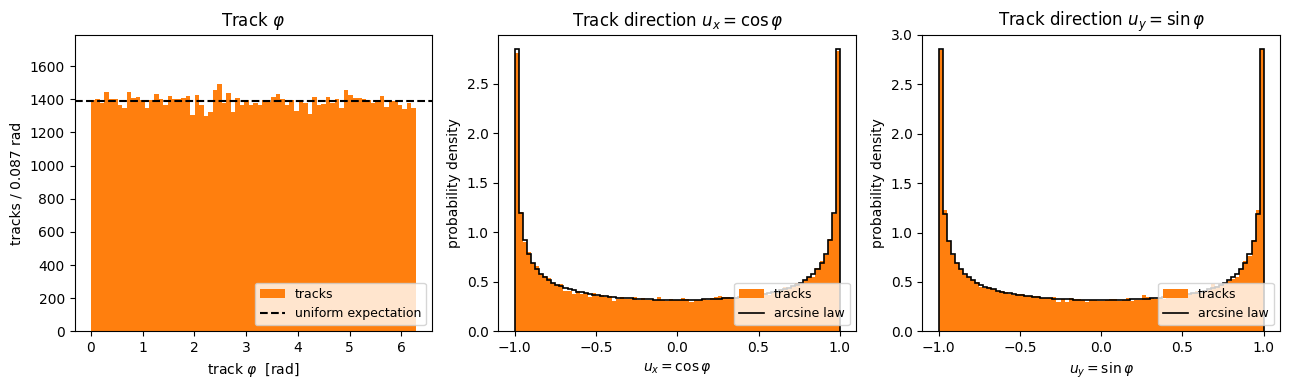

In [4]:
counts_t, edges_t = np.histogram(tracks["phi"], bins=NB_PHI, range=(0.0, 2.0 * np.pi))
stat_t, pval_t = chisquare(counts_t)
print(f"tracks in phi: chi2/ndf = {stat_t:.1f}/{NB_PHI - 1},  p = {pval_t:.3f}")

ux, uy = np.cos(tracks["phi"]), np.sin(tracks["phi"])
edges_u = np.linspace(-1.0, 1.0, 81)
expected_u = mixture_bin_density(edges_u, [1.0])    # arcsine law, R = 1

fig, axes = plt.subplots(1, 3, figsize=(13, 4))

axes[0].stairs(counts_t, edges_t, fill=True, color="tab:orange", label="tracks")
axes[0].axhline(len(tracks) / NB_PHI, color="k", ls="--", label="uniform expectation")
axes[0].set_ylim(0, counts_t.max() * 1.2)
axes[0].set_xlabel(r"track $\varphi$  [rad]")
axes[0].set_ylabel(f"tracks / {2 * np.pi / NB_PHI:.3f} rad")
axes[0].set_title(r"Track $\varphi$")

for ax, u, name in [(axes[1], ux, r"$u_x=\cos\varphi$"), (axes[2], uy, r"$u_y=\sin\varphi$")]:
    ax.hist(u, bins=edges_u, density=True, color="tab:orange", label="tracks")
    ax.stairs(expected_u, edges_u, color="k", lw=1.2, label="arcsine law")
    ax.set_xlabel(name); ax.set_ylabel("probability density")
    ax.set_title(f"Track direction {name}")
for ax in axes: ax.legend(fontsize=9, loc="lower right")

fig.tight_layout(); fig.savefig(os.path.join(FIGDIR, "c3_track_phi_xy.png"), dpi=150)
plt.show()

## 4. Consistency check — hit $\varphi$ vs. track $\varphi$

The smearing model links the two angular distributions. Decompose the position
noise into components radial and tangential to the ray: the radial part does not
change $\varphi$ (to first order), while the tangential part $\delta t \sim
\mathcal N(0,\, 0.001R)$ tilts the hit by

$$\delta\varphi \approx \delta t / R \sim \mathcal N(0,\ 0.001\ \mathrm{rad})
\qquad \text{on every layer.}$$

So the **pull** $(\varphi_\mathrm{hit} - \varphi_\mathrm{track}) / 0.001$ should
be standard normal, independent of layer — a 1 mrad angular resolution. This is
the natural scale for task (d): two tracks closer than a few mrad have
overlapping hits and become genuinely ambiguous to associate.

pull mean = +0.0006,  std = 1.0003  (expect 0, 1)


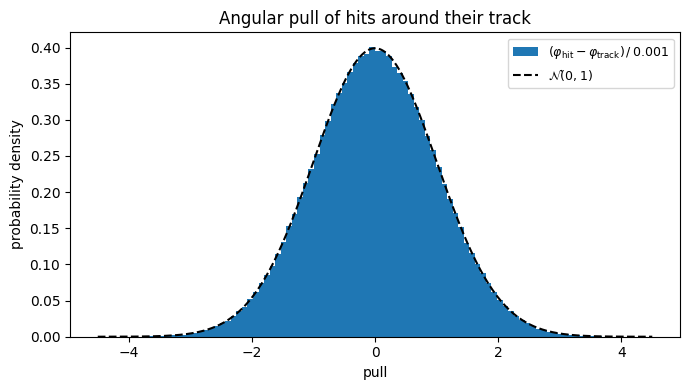

In [5]:
dphi = (df["phi_hit"] - df["phi"] + np.pi) % (2.0 * np.pi) - np.pi   # wrap to [-pi, pi)
pull = dphi / SMEAR
print(f"pull mean = {pull.mean():+.4f},  std = {pull.std():.4f}  (expect 0, 1)")

grid = np.linspace(-4.5, 4.5, 400)
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(pull, bins=100, range=(-4.5, 4.5), density=True, color="tab:blue",
        label=r"$(\varphi_\mathrm{hit}-\varphi_\mathrm{track})\,/\,0.001$")
ax.plot(grid, np.exp(-grid**2 / 2) / np.sqrt(2 * np.pi), "k--", label=r"$\mathcal{N}(0,1)$")
ax.set_xlabel("pull"); ax.set_ylabel("probability density")
ax.set_title(r"Angular pull of hits around their track"); ax.legend(fontsize=9)
fig.tight_layout(); fig.savefig(os.path.join(FIGDIR, "c4_phi_pull.png"), dpi=150)
plt.show()

## Summary

* **Hits in $x$, $y$**: equal-weight 5-layer mixture of arcsine laws, with the
  predicted integrable peaks at $\pm 2, \pm 4, \pm 6, \pm 8, \pm 10$ — the
  bin-integrated analytic overlay matches the data.
* **Hits and tracks in $\varphi$**: flat, as required by isotropic emission and
  angle-independent detector effects. The $\chi^2$ tests pass — for hits only
  after correcting the naive statistic for the cluster overdispersion
  ($c = \mathbb{E}[m^2]/\mathbb{E}[m] \approx 4.8$) caused by the ~4.75 hits of
  each track sharing one $\varphi$.
* **Tracks in $x$, $y$** (unit direction components, since a ray has no unique
  point): arcsine law with $R = 1$, as predicted.
* **Consistency**: the angular pull $(\varphi_\mathrm{hit} -
  \varphi_\mathrm{track})/0.001$ is standard normal — the $\sigma = 0.001R$
  position smearing translates into a layer-independent **1 mrad** angular
  resolution.

Figures saved: `figures/c1_hit_x_y.png`, `c2_hit_phi.png`, `c3_track_phi_xy.png`,
`c4_phi_pull.png`.

**Next (task d):** train a neural network that assigns each hit of an event to
the track that produced it; the 1 mrad resolution found here sets the scale at
which nearby tracks become ambiguous.